# EDA 실험: 네 가지 가설의 채택·기각

간단한 시각화에서 발견한 네 가지 가설을 수명과 비교하고 초기 예측·분류 지표로 사용할지 판단한다. **1~3번은 기각하고, 4번 초기 ΔQ(V) 분산의 로그 지표를 남긴다.** 여기서 기각은 이번 초기 예측 지표로 채택하지 않는다는 뜻이다.

| 가설 | 확인 방법 | 판단 |
|---|---|---|
| 1. Batch2 운전조건으로 단수명 구분 | 단수명(<500)/그 외 분류, 같은 정책 비교 | 다른 배치에 공통 적용하기 어려워 기각 |
| 2. Q 급변 구간의 크기·변화로 수명 구분 | 피크 크기·전압 이동량과 수명의 회귀·상관 | 관계가 약하고 배치별 일관성이 부족해 기각 |
| 3. 이른 knee로 수명 구분 | knee 시점과 수명의 회귀·상관 | 열화가 가속된 뒤 확인되므로 초기 예측 지표로 기각 |
| 4. 초기 `log10_dqv_var`로 수명 설명 | 초기 ΔQ(V) 분산과 수명의 회귀·상관, 도메인 해석 | 세 배치 모두 음의 관계가 나타나 유지 |

분석 단위는 셀 하나이며, 수명이 확인된 129개를 사용한다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact, linregress, spearmanr
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "processed"
BATCHES = ["batch1", "batch2", "batch3"]
KEYS = ["batch", "cell_id"]
sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:.3g}".format
np.random.seed(42)

all_cells = pd.concat([
    pd.read_csv(DATA / f"{batch}_cells.csv").assign(batch=batch) for batch in BATCHES
], ignore_index=True)
all_summary = pd.concat([
    pd.read_csv(DATA / f"{batch}_cycle_summary.csv").assign(batch=batch) for batch in BATCHES
], ignore_index=True)
assert not all_cells.duplicated(KEYS).any()
assert not all_summary.duplicated(KEYS + ["cycle"]).any()

all_cells["variant"] = np.select(
    [all_cells["policy"].str.contains("SLOWCYCLE", na=False),
     all_cells["policy"].str.startswith("VarCharge", na=False),
     all_cells["policy"].str.contains("newstructure", na=False)],
    ["Slowcycle", "VarCharge", "Newstructure"], default="Base"
)
all_cells["protocol"] = all_cells["policy"].str.extract(
    r"^(\d+(?:\.\d+)?C\(\d+(?:\.\d+)?%\)-\d+(?:\.\d+)?C)", expand=False
).fillna(all_cells["policy"])
known = all_cells.dropna(subset=["cycle_life"]).copy()
assert np.isfinite(known["cycle_life"]).all() and known["cycle_life"].gt(0).all()
known["short_life"] = known["cycle_life"] < 500
print(f"전체 {len(all_cells)}개 중 수명 확인 {len(known)}개, 수명 결측 {len(all_cells) - len(known)}개")

def association_table(frame, features):
    rows = []
    for group_name, group in [("All", frame), *list(frame.groupby("batch"))]:
        for feature in features:
            valid = group[[feature, "cycle_life"]].dropna()
            if len(valid) < 3 or valid.nunique().min() < 2:
                continue
            fit = linregress(valid[feature], valid["cycle_life"])
            rows.append({"group": group_name, "feature": feature, "n": len(valid),
                         "Pearson_r": fit.rvalue,
                         "Spearman_rho": spearmanr(valid[feature], valid["cycle_life"]).statistic,
                         "R2": fit.rvalue ** 2, "p_value": fit.pvalue})
    return pd.DataFrame(rows)

# 완전한 직선 관계에서 r와 R²가 1인지 확인한다.
check = association_table(pd.DataFrame({"batch": ["toy"] * 3, "x": [1, 2, 3],
                                      "cycle_life": [100, 200, 300]}), ["x"])
assert np.allclose(check[["Pearson_r", "R2"]], 1)

전체 139개 중 수명 확인 129개, 수명 결측 10개


## 1. Batch2의 단수명은 운전조건으로 구분되는가? → 기각

**가설:** Batch2에 단수명 셀이 더 많으며, 같은 숫자 충전 정책에서도 기본/`newstructure` 설정에 따라 수명이 다르다.

**확인:** 수명을 500사이클 미만/그 외로 분류해 배치별 비율을 비교한다. Fisher 검정으로 Batch2와 나머지 배치의 차이를 확인하고, Batch2 안에서는 두 설정에 공통인 충전 정책끼리 비교한다.

,n,short_n,median_life,short_percent
batch,,,,
batch1,46,0,858,0
batch2,39,28,472,71.8
batch3,44,0,1.01e+03,0


Batch2 vs 나머지 배치: Fisher p=9.68e-20


,n,short_n,median_life,short_percent
variant,,,,
Base,30,28,451,93.3
Newstructure,9,0,904,0


n  median_life
protocol       variant                     
4.8C(80%)-4.8C Base          5          492
               Newstructure  3          809
5.2C(58%)-4C   Base          4          483
               Newstructure  3          904
5.6C(26%)-4.5C Base          6          446
               Newstructure  3          997

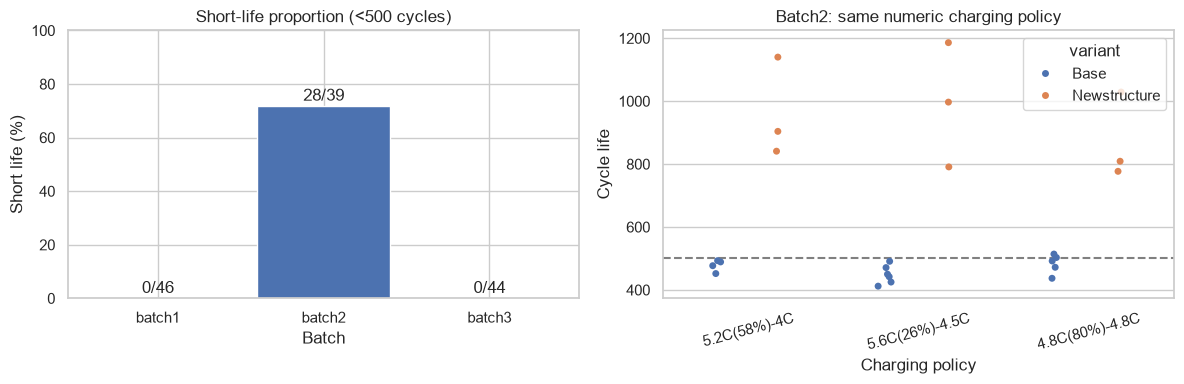

In [2]:
batch_rates = known.groupby("batch").agg(
    n=("cell_id", "size"), short_n=("short_life", "sum"), median_life=("cycle_life", "median")
)
batch_rates["short_percent"] = batch_rates["short_n"] / batch_rates["n"] * 100
display(batch_rates.round(1))
contingency = pd.crosstab(known["batch"].eq("batch2"), known["short_life"]).reindex(
    index=[False, True], columns=[False, True], fill_value=0
)
batch_p = fisher_exact(contingency.to_numpy()).pvalue
print(f"Batch2 vs 나머지 배치: Fisher p={batch_p:.2e}")

batch2 = known.loc[known["batch"].eq("batch2")].copy()
variant_rates = batch2.groupby("variant").agg(
    n=("cell_id", "size"), short_n=("short_life", "sum"), median_life=("cycle_life", "median")
)
variant_rates["short_percent"] = variant_rates["short_n"] / variant_rates["n"] * 100
display(variant_rates.round(1))
shared_protocols = batch2.groupby("protocol")["variant"].nunique().loc[lambda s: s == 2].index
matched = batch2.loc[batch2["protocol"].isin(shared_protocols)]
matched_life = matched.groupby(["protocol", "variant"]).agg(
    n=("cell_id", "size"), median_life=("cycle_life", "median")
)
display(matched_life)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(batch_rates.index, batch_rates["short_percent"])
for position, row in enumerate(batch_rates.itertuples()):
    axes[0].text(position, row.short_percent + 2, f"{row.short_n}/{row.n}", ha="center")
axes[0].set(title="Short-life proportion (<500 cycles)", xlabel="Batch", ylabel="Short life (%)", ylim=(0, 100))
sns.stripplot(data=matched, x="protocol", y="cycle_life", hue="variant", dodge=True, jitter=0.08, ax=axes[1])
axes[1].axhline(500, color="gray", linestyle="--")
axes[1].set(title="Batch2: same numeric charging policy", xlabel="Charging policy", ylabel="Cycle life")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

Batch2에서는 Base 30개 중 28개가 단수명인 반면, `newstructure` 9개에는 단수명이 없었다. 두 설정에 공통으로 존재하는 충전 정책 세 개에서도 수명 중앙값은 Base/`newstructure`가 각각 **492/809, 483/904, 446/997사이클**로 달랐다. 따라서 Batch2 내부에서는 운전 설정과 수명이 나뉘었다.

그러나 같은 Base인 Batch1 46개에는 단수명이 없고, Batch3의 `newstructure`도 수명이 확인된 44개에는 단수명이 없었다(2개는 수명 결측). **Batch2에서 발견한 설정별 구분을 Batch1·3에도 공통으로 적용하기 어려우므로 기각한다.** Base와 `newstructure`는 정책명으로 묶은 설정 그룹이며, 같은 이름이 모든 배치에서 동일한 실제 운전조건을 뜻하지는 않는다.

## 2. Q 급변 구간의 크기와 변화로 수명을 구분할 수 있는가? → 기각

**가설:** Q–V 곡선의 가파른 구간이 초기부터 더 크거나, cycle 10→100 사이 더 많이 이동한 셀은 수명이 다르다.

**확인:** 2.7~3.4 V에서 `|dQ/dV|`가 가장 큰 지점을 찾는다. cycle 10의 피크 크기(Ah/V), cycle 10→100의 피크 전압 이동 크기(mV)를 각각 수명과 회귀·상관으로 비교한다. 예시 곡선과 전체 셀의 관계를 함께 본다.

,group,feature,n,Pearson_r,Spearman_rho,R2,p_value
0,All,peak_height_10,129,-0.0627,-0.0673,0.00393,0.48
1,All,peak_shift_mv,129,-0.344,-0.432,0.118,6.51e-05
2,batch1,peak_height_10,46,-0.24,-0.214,0.0574,0.109
3,batch1,peak_shift_mv,46,-0.226,-0.246,0.0513,0.13
4,batch2,peak_height_10,39,0.0419,0.249,0.00175,0.8
5,batch2,peak_shift_mv,39,-0.435,-0.583,0.189,0.00564
6,batch3,peak_height_10,44,0.341,0.341,0.116,0.0236
7,batch3,peak_shift_mv,44,0.155,-0.045,0.0241,0.315


Cycle 10 피크 전압: 중앙값 3.155 V, 범위 3.144~3.167 V


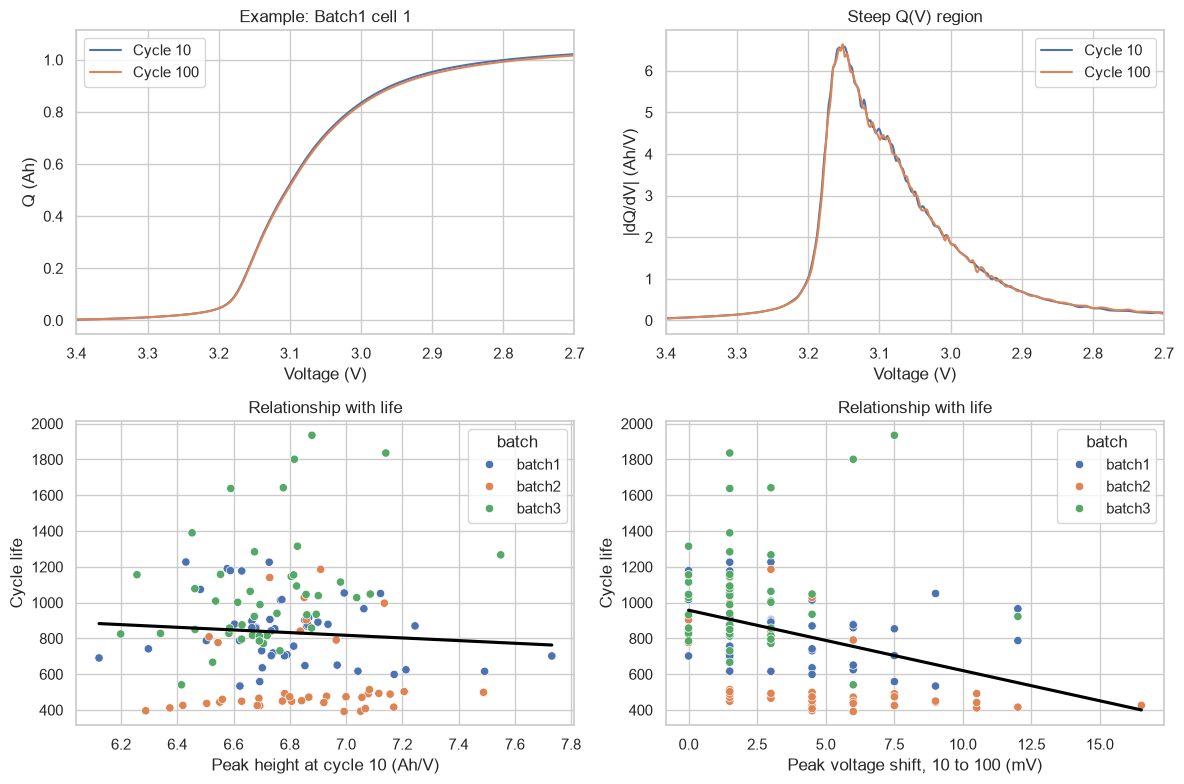

In [3]:
V_WINDOW = (2.7, 3.4)
voltage = pd.read_csv(DATA / "batch1_vdlin.csv")["Vdlin"].to_numpy()
inside = np.flatnonzero((voltage >= V_WINDOW[0]) & (voltage <= V_WINDOW[1]))
assert len(inside) > 2 and np.all(np.diff(voltage) < 0)
profile_rows, example_q = [], {}
for batch in BATCHES:
    v = pd.read_csv(DATA / f"{batch}_vdlin.csv")["Vdlin"].to_numpy()
    assert np.allclose(v, voltage, rtol=0, atol=1e-12)
    with np.load(DATA / f"{batch}_cycle_profiles.npz", allow_pickle=False) as archive:
        for cell_id in all_cells.loc[all_cells["batch"].eq(batch), "cell_id"]:
            cycles = archive[f"cell_{cell_id}_cycle"]
            indices = [np.flatnonzero(cycles == cycle) for cycle in [10, 100]]
            assert all(len(index) == 1 for index in indices), f"{batch}/{cell_id}: cycle 10 또는 100 없음"
            q = archive[f"cell_{cell_id}_qdlin"]
            assert q.shape == (len(cycles), len(v))
            q10, q100 = q[indices[0][0]], q[indices[1][0]]
            assert np.isfinite([q10, q100]).all()
            slopes = [np.abs(np.gradient(curve, v)) for curve in [q10, q100]]
            # ponytail: 최대 피크만 비교한다. 피크가 서로 바뀌는 셀은 별도 피크 추적으로 확인한다.
            peaks = [inside[np.argmax(slope[inside])] for slope in slopes]
            variance = np.var(q100 - q10)
            profile_rows.append({"batch": batch, "cell_id": cell_id,
                                 "peak_voltage_10": v[peaks[0]],
                                 "peak_height_10": slopes[0][peaks[0]],
                                 "peak_shift_mv": abs(v[peaks[1]] - v[peaks[0]]) * 1000,
                                 "log10_dqv_var": np.log10(variance) if variance > 0 else np.nan})
            if batch == "batch1" and cell_id == 1:
                example_q = {10: q10.copy(), 100: q100.copy()}
            del q

features = known.merge(pd.DataFrame(profile_rows), on=KEYS, validate="one_to_one")
assert len(features) == len(known)
peak_stats = association_table(features, ["peak_height_10", "peak_shift_mv"])
display(peak_stats)
print(f"Cycle 10 피크 전압: 중앙값 {features['peak_voltage_10'].median():.3f} V, "
      f"범위 {features['peak_voltage_10'].min():.3f}~{features['peak_voltage_10'].max():.3f} V")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for cycle, curve in example_q.items():
    axes[0, 0].plot(voltage, curve, label=f"Cycle {cycle}")
    axes[0, 1].plot(voltage, np.abs(np.gradient(curve, voltage)), label=f"Cycle {cycle}")
axes[0, 0].set(title="Example: Batch1 cell 1", xlabel="Voltage (V)", ylabel="Q (Ah)", xlim=(3.4, 2.7))
axes[0, 1].set(title="Steep Q(V) region", xlabel="Voltage (V)", ylabel="|dQ/dV| (Ah/V)", xlim=(3.4, 2.7))
for ax in axes[0]:
    ax.legend()
for ax, feature, label in zip(axes[1], ["peak_height_10", "peak_shift_mv"],
                              ["Peak height at cycle 10 (Ah/V)", "Peak voltage shift, 10 to 100 (mV)"]):
    sns.scatterplot(data=features, x=feature, y="cycle_life", hue="batch", ax=ax)
    sns.regplot(data=features, x=feature, y="cycle_life", scatter=False, ci=None, color="black", ax=ax)
    ax.set(title="Relationship with life", xlabel=label, ylabel="Cycle life")
plt.tight_layout()
plt.show()

2.7~3.4 V의 Q–V 곡선에서 가장 가파른 지점을 찾아 cycle 10의 `|dQ/dV|` 피크 크기와 cycle 10→100의 피크 전압 이동량을 수명과 비교했다. **피크 크기는 r=−0.063, p=0.480으로 수명과 뚜렷한 관계가 없었다.** 이동량도 전체 r=−0.344, R²=0.118에 그쳤고, 배치별 r는 −0.226/−0.435/+0.155로 방향이 일정하지 않았다.

**특정 전압에서 Q가 급변한다는 사실이나 그 피크 크기·위치 변화만으로는 수명을 충분히 설명하기 어려워 기각한다.** 이는 현재 추출한 지표의 판단이며, Q 변화의 모든 형태가 수명과 무관하다는 뜻은 아니다.

## 3. 이른 knee로 단수명을 구분할 수 있는가? → 기각

**가설:** 용량 감소가 빨라지는 knee 시점이 이를수록 최종 수명이 짧다.

**확인:** cycle 100 이후 열화곡선에 이어 붙인 두 직선을 맞춘다. 앞뒤 최소 50개 관측값을 남기고, 직선 하나보다 오차가 10% 이상 줄며 뒤쪽 감소가 더 빠른 지점을 후보로 정한다. 11·21·41개 이동 중앙값에서 모두 후보가 나오고 위치 차이가 20사이클 이하면 비교에 사용한다. 수명 이후 기록은 제외한다.

,n,detected_knees
batch,,
batch1,46,45
batch2,39,38
batch3,44,44


,group,feature,n,Pearson_r,Spearman_rho,R2,p_value
0,All,knee_cycle,127,0.975,0.966,0.95,4.72e-83
1,batch1,knee_cycle,45,0.827,0.866,0.684,2.57e-12
2,batch2,knee_cycle,38,0.996,0.97,0.991,1.68e-38
3,batch3,knee_cycle,44,0.991,0.98,0.983,1.33e-38


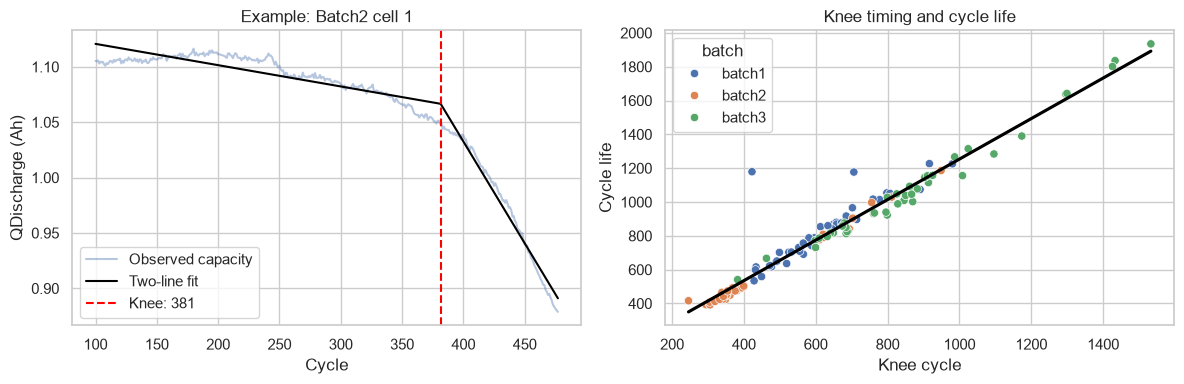

In [4]:
KNEE_START_CYCLE = 100
KNEE_WINDOWS = [11, 21, 41]
MIN_SEGMENT_POINTS = 50
MIN_SSE_GAIN = 0.10

def fit_knee(x, y):
    """이어 붙인 두 직선으로 꺾임을 찾습니다. 직선이면 꺾임이 없다고 봅니다."""
    if len(x) < 2 * MIN_SEGMENT_POINTS + 1:
        return None
    base = np.column_stack([np.ones(len(x)), x])
    base_fit = base @ np.linalg.lstsq(base, y, rcond=None)[0]
    base_sse = np.sum((y - base_fit) ** 2)
    if base_sse <= 1e-12:
        return None
    best = None
    for knee in np.linspace(x[MIN_SEGMENT_POINTS], x[-MIN_SEGMENT_POINTS - 1], 80):
        design = np.column_stack([base, np.maximum(0, x - knee)])
        coef = np.linalg.lstsq(design, y, rcond=None)[0]
        fit = design @ coef
        sse = np.sum((y - fit) ** 2)
        if best is None or sse < best["sse"]:
            best = {"knee_cycle": knee, "sse": sse, "fit": fit,
                    "slope_before": coef[1], "slope_after": coef[1] + coef[2]}
    best["sse_gain"] = 1 - best["sse"] / base_sse
    best["candidate"] = (best["sse_gain"] >= MIN_SSE_GAIN and
                         best["slope_after"] < min(best["slope_before"], 0))
    return best

# 꺾임 위치를 아는 예시와 그냥 직선인 예시로 코드가 맞게 동작하는지 확인합니다.
toy_x = np.arange(1, 301, dtype=float)
toy_y = 1.1 - 0.00005 * toy_x - 0.0005 * np.maximum(0, toy_x - 180)
toy_result = fit_knee(toy_x, toy_y)
assert toy_result["candidate"] and abs(toy_result["knee_cycle"] - 180) < 5
assert fit_knee(toy_x, 1.1 - 0.0001 * toy_x) is None

knee_rows = []
for row in known.itertuples(index=False):
    track = all_summary.loc[
        all_summary["batch"].eq(row.batch) & all_summary["cell_id"].eq(row.cell_id)
        & all_summary["cycle"].between(KNEE_START_CYCLE, row.cycle_life)
    ].sort_values("cycle").dropna(subset=["QDischarge"])
    x = track["cycle"].to_numpy(dtype=float)
    q = track["QDischarge"].to_numpy()
    found = {}
    for window in KNEE_WINDOWS:
        smooth = pd.Series(q).rolling(window, center=True, min_periods=1).median().to_numpy()
        fit = fit_knee(x, smooth)
        if fit is not None and fit["candidate"]:
            found[window] = fit
    stable = len(found) == len(KNEE_WINDOWS) and np.ptp([f["knee_cycle"] for f in found.values()]) <= 20
    knee_rows.append({"batch": row.batch, "cell_id": row.cell_id,
                      "knee_cycle": found[21]["knee_cycle"] if stable else np.nan})

knees = known.merge(pd.DataFrame(knee_rows), on=KEYS, validate="one_to_one")
display(knees.groupby("batch").agg(n=("cell_id", "size"), detected_knees=("knee_cycle", "count")))
stable_knees = knees.dropna(subset=["knee_cycle"])
knee_stats = association_table(stable_knees, ["knee_cycle"])
display(knee_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
example_life = known.loc[known["batch"].eq("batch2") & known["cell_id"].eq(1), "cycle_life"].iloc[0]
example = all_summary.loc[
    all_summary["batch"].eq("batch2") & all_summary["cell_id"].eq(1)
    & all_summary["cycle"].between(KNEE_START_CYCLE, example_life)
].sort_values("cycle")
x = example["cycle"].to_numpy(dtype=float)
q = example["QDischarge"].to_numpy()
smooth = pd.Series(q).rolling(21, center=True, min_periods=1).median().to_numpy()
fit = fit_knee(x, smooth)
axes[0].plot(x, q, alpha=0.4, label="Observed capacity")
if fit is not None and fit["candidate"]:
    axes[0].plot(x, fit["fit"], color="black", label="Two-line fit")
    axes[0].axvline(fit["knee_cycle"], linestyle="--", color="red", label=f"Knee: {fit['knee_cycle']:.0f}")
axes[0].set(title="Example: Batch2 cell 1", xlabel="Cycle", ylabel="QDischarge (Ah)")
axes[0].legend()
sns.scatterplot(data=stable_knees, x="knee_cycle", y="cycle_life", hue="batch", ax=axes[1])
sns.regplot(data=stable_knees, x="knee_cycle", y="cycle_life", scatter=False, ci=None, color="black", ax=axes[1])
axes[1].set(title="Knee timing and cycle life", xlabel="Knee cycle", ylabel="Cycle life")
plt.tight_layout()
plt.show()

전체 열화곡선에서 knee를 찾을 수 있었던 127개 셀은 knee 시점과 수명의 관계가 강했다(**r=0.975, R²=0.950**). knee가 이른 셀일수록 최종 수명도 짧았다.

하지만 이번 knee는 수명까지의 곡선과 꺾임 이후 기록을 보고 찾았다. **knee를 확인할 때는 이미 용량 감소가 빨라진 뒤이므로, 열화 전에 수명을 예측·분류하려는 목적에는 늦다. 따라서 초기 예측 지표로는 기각한다.** 후기 상태를 설명하는 연관성 자체는 관찰됐다.

## 4. 초기 `log10_dqv_var`가 클수록 수명이 짧은가? → 유지

**가설:** 초기 사이클 사이 Q–V 곡선의 변화가 클수록 수명이 짧다.

**확인:** `ΔQ(V) = Q100(V) − Q10(V)`의 전압별 분산에 log10을 적용한다. 전체 셀과 각 배치 안에서 `cycle_life`와 회귀·상관으로 비교한다.

,group,feature,n,Pearson_r,Spearman_rho,R2,p_value
0,All,log10_dqv_var,129,-0.851,-0.892,0.724,2.9e-37
1,batch1,log10_dqv_var,46,-0.886,-0.871,0.785,2.7e-16
2,batch2,log10_dqv_var,39,-0.902,-0.709,0.813,4.67e-15
3,batch3,log10_dqv_var,44,-0.702,-0.797,0.493,1.11e-07


초기 ΔQ(V) 분산 범위: 7.96e-06~8.21e-04 Ah²


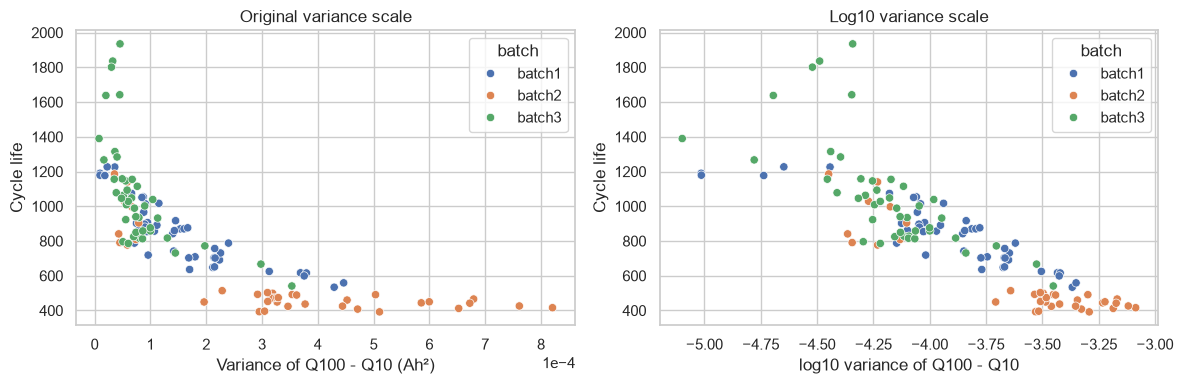

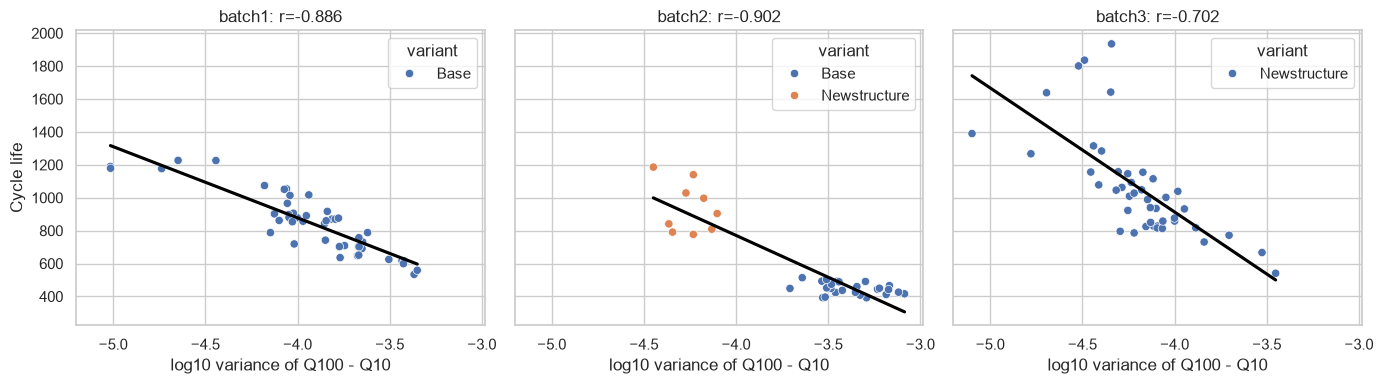

In [5]:
dqv_stats = association_table(features, ["log10_dqv_var"])
display(dqv_stats)


# 같은 셀을 원래 분산 축과 log10 축에서 비교한다.
features["dqv_var"] = np.power(10.0, features["log10_dqv_var"])
print(f"초기 ΔQ(V) 분산 범위: {features['dqv_var'].min():.2e}~{features['dqv_var'].max():.2e} Ah²")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feature, title, xlabel in zip(
    axes, ["dqv_var", "log10_dqv_var"], ["Original variance scale", "Log10 variance scale"],
    ["Variance of Q100 - Q10 (Ah²)", "log10 variance of Q100 - Q10"]
):
    sns.scatterplot(data=features, x=feature, y="cycle_life", hue="batch", ax=ax)
    ax.set(title=title, xlabel=xlabel, ylabel="Cycle life")
axes[0].ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for ax, batch in zip(axes, BATCHES):
    group = features.loc[features["batch"].eq(batch)]
    sns.scatterplot(data=group, x="log10_dqv_var", y="cycle_life", hue="variant", ax=ax)
    sns.regplot(data=group, x="log10_dqv_var", y="cycle_life", scatter=False, ci=None, color="black", ax=ax)
    r = dqv_stats.loc[dqv_stats["group"].eq(batch), "Pearson_r"].iloc[0]
    ax.set(title=f"{batch}: r={r:.3f}", xlabel="log10 variance of Q100 - Q10", ylabel="Cycle life")
plt.tight_layout()
plt.show()

**로그 그래프를 그린 이유:** cycle 10과 100의 Q–V 곡선을 같은 전압에서 뺀 `ΔQ(V)=Q100(V)−Q10(V)`의 분산을 비교하기 위해서다. 실제 분산 범위는 **7.96×10⁻⁶~8.21×10⁻⁴ Ah²**로 약 103배 차이가 난다. 원래 축에서는 작은 값들이 한쪽에 몰리지만, `log10(분산)`으로 그리면 10배 차이가 축에서 같은 간격으로 표현돼 셀 간 차이와 수명 경향을 읽기 쉽다. EDA에는 같은 셀의 원래 분산 축과 로그 축을 나란히 그렸다. 로그는 값의 크기 순서를 바꾸지 않는다.

**실제로 나타난 관계:** 전체 129개에서 `log10_dqv_var`와 원래 단위의 `cycle_life`는 **Pearson r=−0.851, Spearman ρ=−0.892, 단순 회귀 R²=0.724**였다. Batch1/2/3 안에서도 Pearson r가 **−0.886/−0.902/−0.702**로 모두 음수였다. 따라서 초기 곡선 변화의 분산이 큰 셀일수록 수명이 짧은 경향이 확인됐다. R²는 이 데이터에서의 직선 관계 요약이며 새 셀의 예측 성능은 아니다. 원 논문도 같은 초기 ΔQ(V) 분산을 로그 지표로 사용하지만, 논문의 log–log 그림과 달리 이번 관계 분석은 **수명에는 로그를 취하지 않았다.** [Severson et al., Nature Energy (2019), Fig. 2](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)

**도메인 관점의 의미:** 이 분산은 용량이 총 몇 Ah 줄었는지만 보는 값이 아니다. 모든 전압에서 ΔQ가 일정하면 분산은 작고, 일부 전압 구간에서 변화가 더 크면 분산은 커진다. 따라서 큰 분산은 초기 Q–V 곡선이 전압에 따라 더 불균일하게 변했다는 뜻이다. 원 논문은 이를 전압에 따른 에너지 소산 변화의 불균일성과 연결하며, 전압 곡선에는 총 방전용량에서 아직 보이지 않는 열화가 먼저 나타날 수 있다고 설명한다. [원 논문, pp. 387–388](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)

**수명과 연결될 수 있는 이유:** 원 논문이 다룬 LFP/흑연 셀에서는 리튬이 빠진 상태의 음극 활성물질 손실이 초기 총용량 감소 없이 전압 곡선을 바꿀 수 있다. 이 손실이 누적돼 리튬을 받아들일 음극 용량이 부족해지면 리튬 도금(음극 표면에 리튬이 금속으로 쌓이는 현상)과 빠른 용량 감소로 이어질 수 있으며, 가용 리튬 손실도 함께 관찰됐다. 이를 바탕으로 **초기 ΔQ(V) 분산이 큰 셀은 총용량 감소가 뚜렷해지기 전부터 내부 열화가 더 진행돼 최종 수명이 짧을 수 있다**고 해석한다. 이는 논문에 근거한 가능한 설명이며, 현재 데이터로 개별 셀의 열화 원인을 확정한 것은 아니다. [원 논문, p. 388](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)

## 최종 정리

| 가설 | EDA 판단 | 이유 |
|---|---|---|
| 1. Batch2 운전조건에 따른 단수명 구분 | 기각 | Batch2의 구분 기준을 다른 배치에 공통 적용하기 어려움 |
| 2. Q 급변 구간의 크기·변화 | 기각 | 크기와 수명의 관계가 약하고 이동량도 배치 간 일관성이 부족함 |
| 3. 이른 knee로 수명 구분 | 기각 | 이미 빠른 열화를 관측한 뒤여서 초기 예측 목적에 늦음 |
| 4. 초기 ΔQ(V) 분산의 로그 지표 | 유지 | 세 배치 모두 수명과 음의 관계이며 초기 전압 곡선의 열화 신호로 해석 가능 |

**간단한 한계:** 상관관계는 원인을 입증하지 않는다. 배치·운전 설정 차이와 일부 수명값의 종료 기준은 추가 확인 대상이다.